## Lesson 3.2：谱刚性的极限——老化速度与真理的崩溃

<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3798/3788400364.py:51: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Log Aging: $u_n \sim 1/\ln(n)$\n(Skeleton Preserved)", fontsize=12)
/tmp/ipykernel_3798/3788400364.py:59: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Linear Aging: $u_n \sim 1/n$\n(Skeleton Crushed)", fontsize=12)


正在模拟两个平行的宇宙演化...


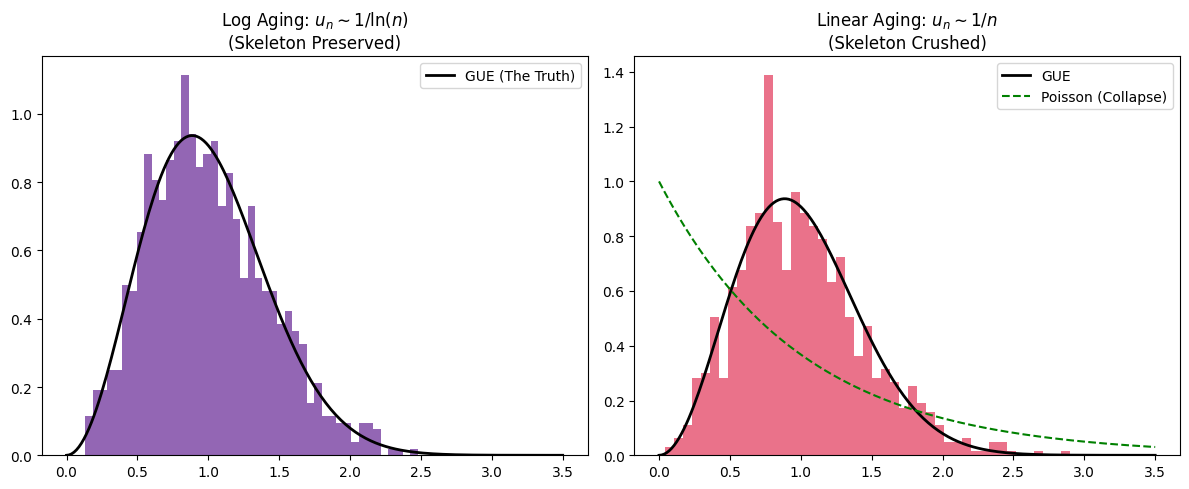

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# Lesson 3.2: 谱稳定性压力测试 (Log vs. Linear Aging)
# =================================================================
N = 1000
T_steps = 400
k_noise = 25

def run_evolution(decay_type='log'):
    A_base = np.random.randn(N, N) + 1j * np.random.randn(N, N)
    U_total = np.eye(N, dtype=complex)
    
    for t in range(2, T_steps + 2):
        # 衰老法则对比
        if decay_type == 'log':
            # 论文路径: 极慢衰减 [cite: 356, 366]
            amplitude = k_noise / np.log(t)
        else:
            # 激进路径: 剧烈衰减 (线性)
            amplitude = k_noise / t 
            
        A_t = A_base + amplitude * (np.random.randn(N, N) + 1j * np.random.randn(N, N))
        Q_t, _ = np.linalg.qr(A_t)
        U_total = Q_t @ U_total
        
    eigvals = np.linalg.eigvals(U_total)
    s = np.diff(np.sort(np.angle(eigvals)))
    return s / np.mean(s)

# -----------------------------------------------------------------
# 3. 运行对比实验
# -----------------------------------------------------------------
print("正在模拟两个平行的宇宙演化...")
s_log = run_evolution('log')
s_linear = run_evolution('linear')

# -----------------------------------------------------------------
# 4. 可视化：观察真理的崩塌
# -----------------------------------------------------------------
plt.figure(figsize=(12, 5))
x_plot = np.linspace(0, 3.5, 200)
gue = (32/(np.pi**2)) * (x_plot**2) * np.exp(-(4/np.pi)*(x_plot**2))
poisson = np.exp(-x_plot)

# 左图：顺应天意的对数老化
plt.subplot(1, 2, 1)
plt.hist(s_log, bins=45, density=True, color='indigo', alpha=0.6)
plt.plot(x_plot, gue, 'k-', lw=2, label='GUE (The Truth)')
plt.title("Log Aging: $u_n \sim 1/\ln(n)$\n(Skeleton Preserved)", fontsize=12)
plt.legend()

# 右图：激进的线性老化
plt.subplot(1, 2, 2)
plt.hist(s_linear, bins=45, density=True, color='crimson', alpha=0.6)
plt.plot(x_plot, gue, 'k-', lw=2, label='GUE')
plt.plot(x_plot, poisson, 'g--', label='Poisson (Collapse)')
plt.title("Linear Aging: $u_n \sim 1/n$\n(Skeleton Crushed)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()